## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize, LinearConstraint, Bounds
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import control as ct
%matplotlib widget

## Define step response function

### Overdamped

In [7]:
def step_response_over_damped(K,xi,wn):
    s1      = (-xi + np.sqrt(xi**2 -1))*wn
    s2      = (-xi - np.sqrt(xi**2 -1))*wn
    tau1    = -1/s1
    tau2    = -1/s2
    return lambda t: K * (1 - 1/(tau1-tau2)*(tau1*np.exp(-t/tau1) - tau2*np.exp(-t/tau2)))


### Critically damped

In [8]:

def step_response_critically_damped(K,xi,wn):
    s1      = -xi*wn
    tau1    = -1/s1
    return lambda t: K * (1 - (1 + t/tau1)*np.exp(-t/tau1))

### Underdamped

In [9]:

def step_response_under_damped(K,xi,wn):
    phi = math.acos(xi)
    wp  = wn * np.sqrt(1-xi**2)
    return lambda t : K * (1 - 1/np.sqrt(1-xi**2)*np.exp(-xi*wn*t)*math.sin(wp*t + phi))

### General case

In [10]:
def step_response(K,xi,wn):
    if xi > 1:
        return step_response_over_damped(K,xi,wn)
    elif xi == 1:
        return step_response_critically_damped(K,xi,wn)
    else:
        return step_response_under_damped(K,xi,wn)

### Function to plot results

In [11]:
def plot_response(sr):
    tf      = 1.5
    dt      = 1e-3   
    N       = int(tf/dt)
    y       = np.zeros(N)
    T       = np.arange(0,tf,dt)
    for t, i in zip(T, np.arange(0,N,1)):
        y[i]    = sr(t)
    plt.plot(T,y)
    plt.xlabel('time')
    plt.ylabel('response')    
    return y

## Main Code

### Controlled system $G(s)$

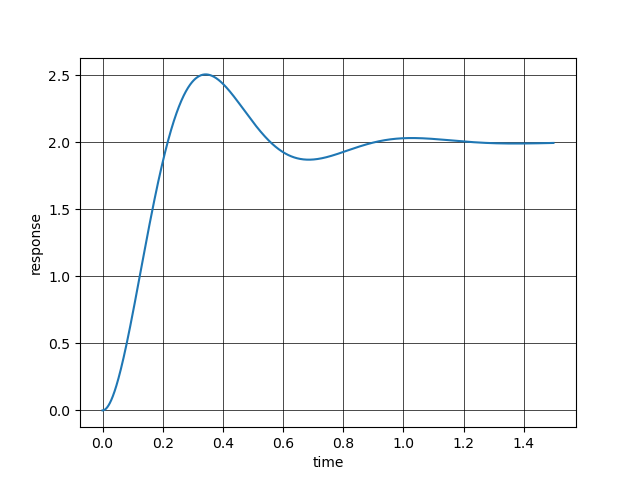

In [12]:
if __name__ == '__main__':
    K       = 2
    wn      = 10
    xi      = 0.4
    sr      = step_response(K,xi,wn)
    fig = plt.figure(1)
    plot_response(sr)    
    plt.grid(color='k', linestyle='-', linewidth=0.5)
    plt.show()    


### Ziegler Nichols PID gain tuning

- Set $k_d = k_i = 0$
- Increase $k_p$ so that an oscillating (but stable) system is obtained
- Record $K_{osc}$ and $T_{osc}$
- Set
    - $kp = 0.6 \, K_{osc}$
    - $k_i = 1.2\frac{K_{osc}}{T_{osc}}$
    - $kd = 0.075\,K_{osc}\,T_{osc}$
- Manually tune $k_p$, $k_i$ and $k_d$ based on these values

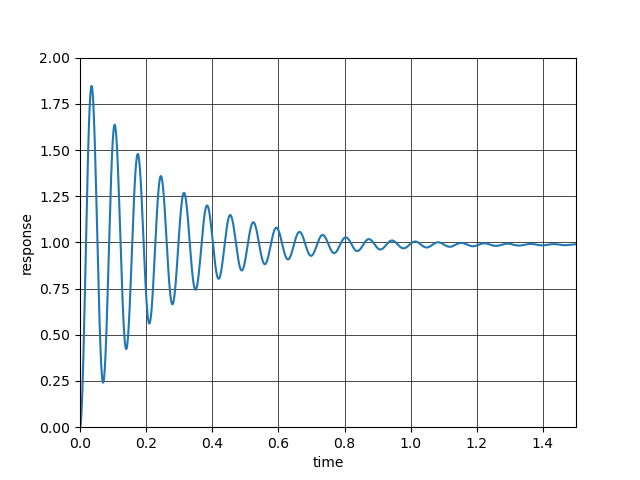

In [16]:
if __name__ == '__main__':
    kp      = 40
    kbf     = kp*K/(1 + kp*K)
    xibf    = xi/(np.sqrt(1 + kp*K))
    wbf     = wn*np.sqrt(1 + kp*K)    
    sr      = step_response(kbf,xibf,wbf)
    fig     = plt.figure(2,clear = True)
    plot_response(sr)    
    plt.grid(color='k', linestyle='-', linewidth=0.5)
    plt.xlim([0,1.5])
    plt.ylim([0,2])
    plt.show()    

- We obtain for $K_{osc} = 40$:
    - $t2 = 0.4012$ s
    - $t1 = 0.4711$ s
    - $\Rightarrow T_{osc} = t1-t2 \approx 0.07$ s

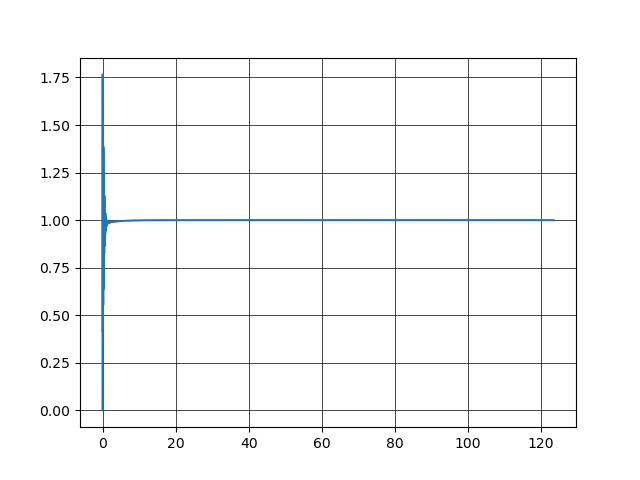

kp =  24.0
ki =  6.857142857142857
kd =  0.0


In [25]:
if __name__ == '__main__':
    Kosc    = 40
    Tosc    = 0.07
    kp      = 0.6*Kosc
    tau_i   = 0.5*Tosc
    tau_d   = 0.125*Tosc
    ki      = kp/tau_i           *0.01
    kd      = tau_d*kp           *0

    C       = ct.tf([kd,kp,ki],[1,0])
    G       = ct.tf([K*wn**2],[1,2*xi*wn,wn**2])
    Gbf     = C*G/(1+C*G)
    # sys_pid = ct.tf([ wn**2*K * kd, wn**2*K * kp, wn**2*K * ki],[1, 2*xi*wn + kd*wn**2*K, wn**2 + wn**2*K * kp, wn**2*K * ki  ])
    T, ypid = ct.step_response(Gbf)
    
    fig = plt.figure(3,clear=True)    
    plt.plot(T,ypid)
    plt.grid(color='k', linestyle='-', linewidth=0.5)
    # plt.xlim([-0.01,0.4])
    # plt.ylim([0,1.75])    
    plt.show()    
    print('kp = ', kp)
    print('ki = ', ki)
    print('kd = ', kd)
    

In [ ]:
if __name__ == '__main__':
    k       = 200
    G       = ct.tf([k],[1,10,31,k+30])
    T, ypid = ct.step_response(G)    
    fig = plt.figure(3,clear=True)    
    plt.plot(T,ypid)
    plt.grid(color='k', linestyle='-', linewidth=0.5)
    plt.xlim([-0.01,40])
    plt.ylim([-3,4])    
    plt.show()    
